In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.font_manager import FontProperties, fontManager

In [10]:
topks = [0.05, 0.1, 0.2]
esp_partition = 0.3

In [11]:
dfour5 = pd.read_csv(
    f"../output/our_{topks[0]}_esp_partition{esp_partition}.csv",
    header=None,
    names=["datasets", "right", "all"],
)

dfour10 = pd.read_csv(
    f"../output/our_{topks[1]}_esp_partition{esp_partition}.csv",
    header=None,
    names=["datasets", "right", "all"],
)

dfour20 = pd.read_csv(
    f"../output/our_{topks[2]}_esp_partition{esp_partition}.csv",
    header=None,
    names=["datasets", "right", "all"],
)


dfenzypick5 = pd.read_csv(
    f"../output/enzypick_{topks[0]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)
dfenzypick10 = pd.read_csv(
    f"../output/enzypick_{topks[1]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)
dfenzypick20 = pd.read_csv(
    f"../output/enzypick_{topks[2]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)


dfesp5 = pd.read_csv(
    f"../output/esp_{topks[0]}.csv", header=None, names=["datasets", "right", "all"]
)
dfesp10 = pd.read_csv(
    f"../output/esp_{topks[1]}.csv", header=None, names=["datasets", "right", "all"]
)
dfesp20 = pd.read_csv(
    f"../output/esp_{topks[2]}.csv", header=None, names=["datasets", "right", "all"]
)

dfpuepp5 = pd.read_csv(
    f"../output/puepp_{topks[0]}.csv", header=None, names=["datasets", "right", "all"]
)
dfpuepp10 = pd.read_csv(
    f"../output/puepp_{topks[1]}.csv", header=None, names=["datasets", "right", "all"]
)
dfpuepp20 = pd.read_csv(
    f"../output/puepp_{topks[2]}.csv", header=None, names=["datasets", "right", "all"]
)

In [12]:
def processdf(df, whichtop, source):
    dfnew = df.copy()
    dfnew["acc"] = dfnew["right"] / dfnew["all"]
    dfnew["topk"] = whichtop
    dfnew["source"] = source
    return dfnew

In [13]:
dfour5_combine = processdf(df=dfour5, whichtop=5, source="P450Mining")
dfour10_combine = processdf(df=dfour10, whichtop=10, source="P450Mining")
dfour20_combine = processdf(df=dfour20, whichtop=20, source="P450Mining")

dfenzypick5_combine = processdf(df=dfenzypick5, whichtop=5, source="enzypick")
dfenzypick10_combine = processdf(df=dfenzypick10, whichtop=10, source="enzypick")
dfenzypick20_combine = processdf(df=dfenzypick20, whichtop=20, source="enzypick")

dfesp5_combine = processdf(df=dfesp5, whichtop=5, source="esp")
dfesp10_combine = processdf(df=dfesp10, whichtop=10, source="esp")
dfesp20_combine = processdf(df=dfesp20, whichtop=20, source="esp")

dfpuepp5_combine = processdf(df=dfpuepp5, whichtop=5, source="puepp")
dfpuepp10_combine = processdf(df=dfpuepp10, whichtop=10, source="puepp")
dfpuepp20_combine = processdf(df=dfpuepp20, whichtop=20, source="puepp")

In [ ]:
dffinal = pd.concat(
    [
        dfour5_combine,
        dfour10_combine,
        dfour20_combine,
        dfenzypick5_combine,
        dfenzypick10_combine,
        dfenzypick20_combine,
        dfesp5_combine,
        dfesp10_combine,
        dfesp20_combine,
        dfpuepp5_combine,
        dfpuepp10_combine,
        dfpuepp20_combine,
    ]
)

In [15]:
dffinalgroup = dffinal.groupby(["datasets"])

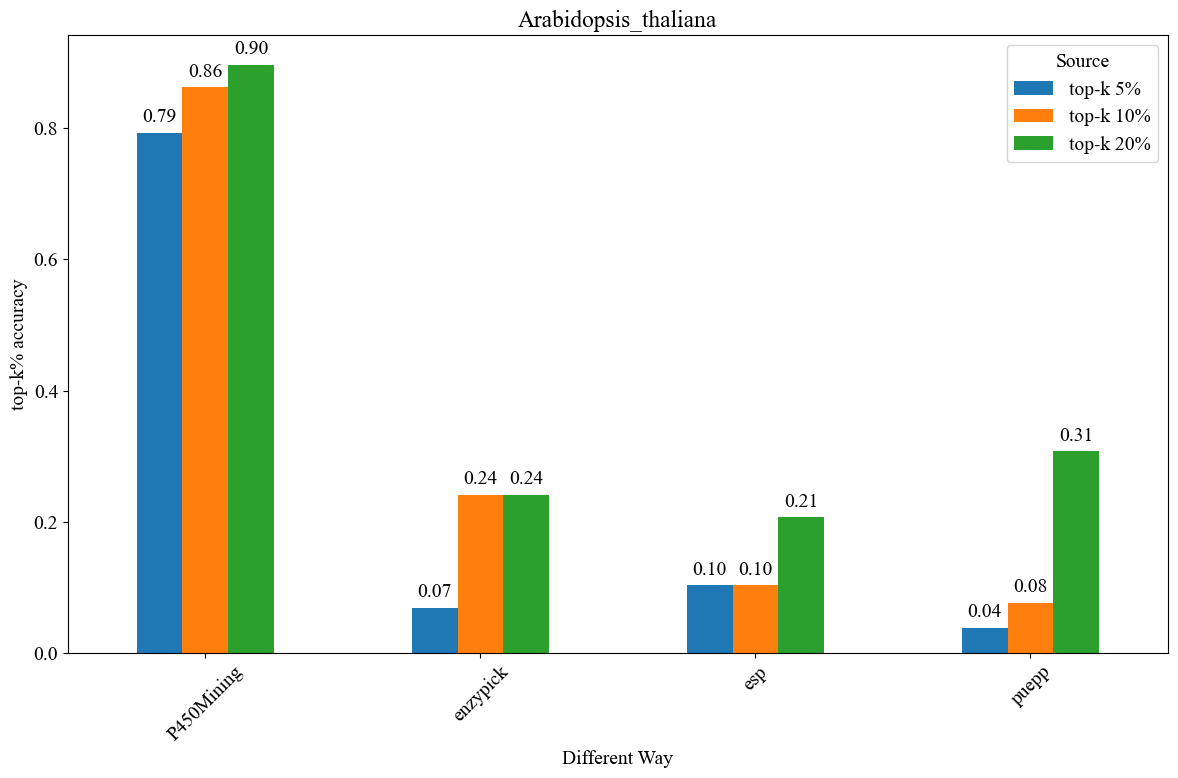

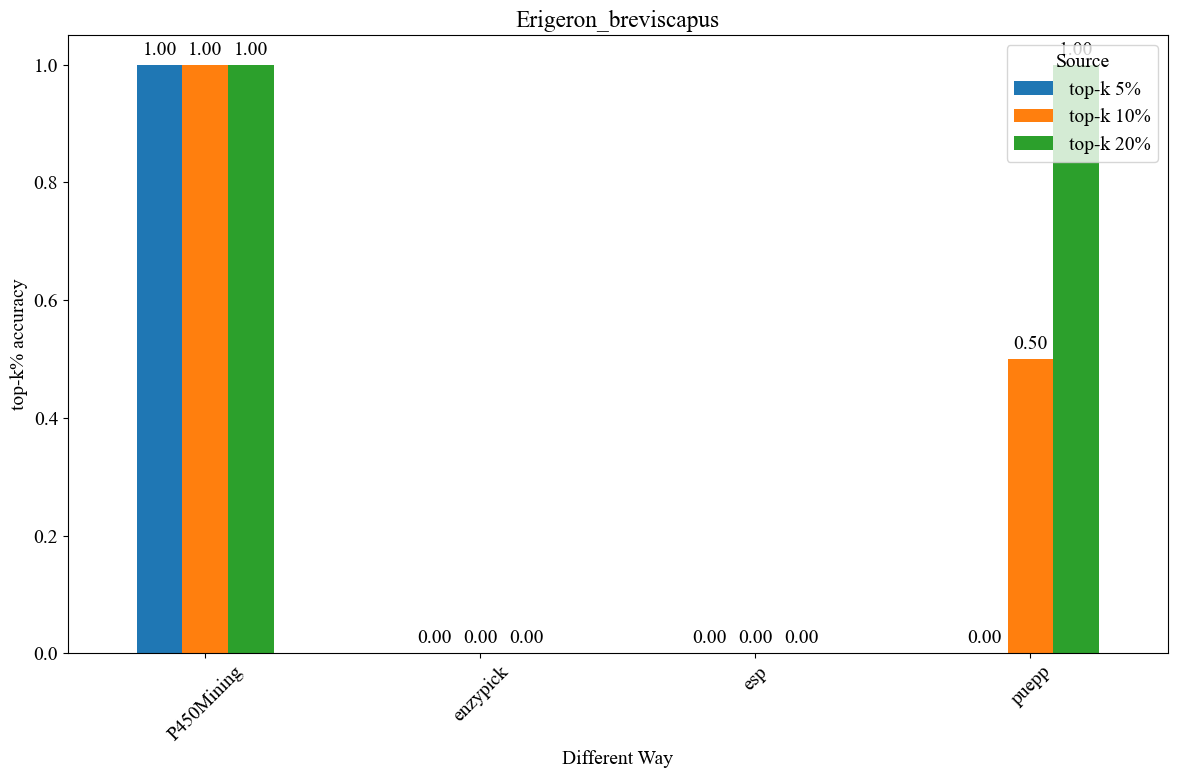

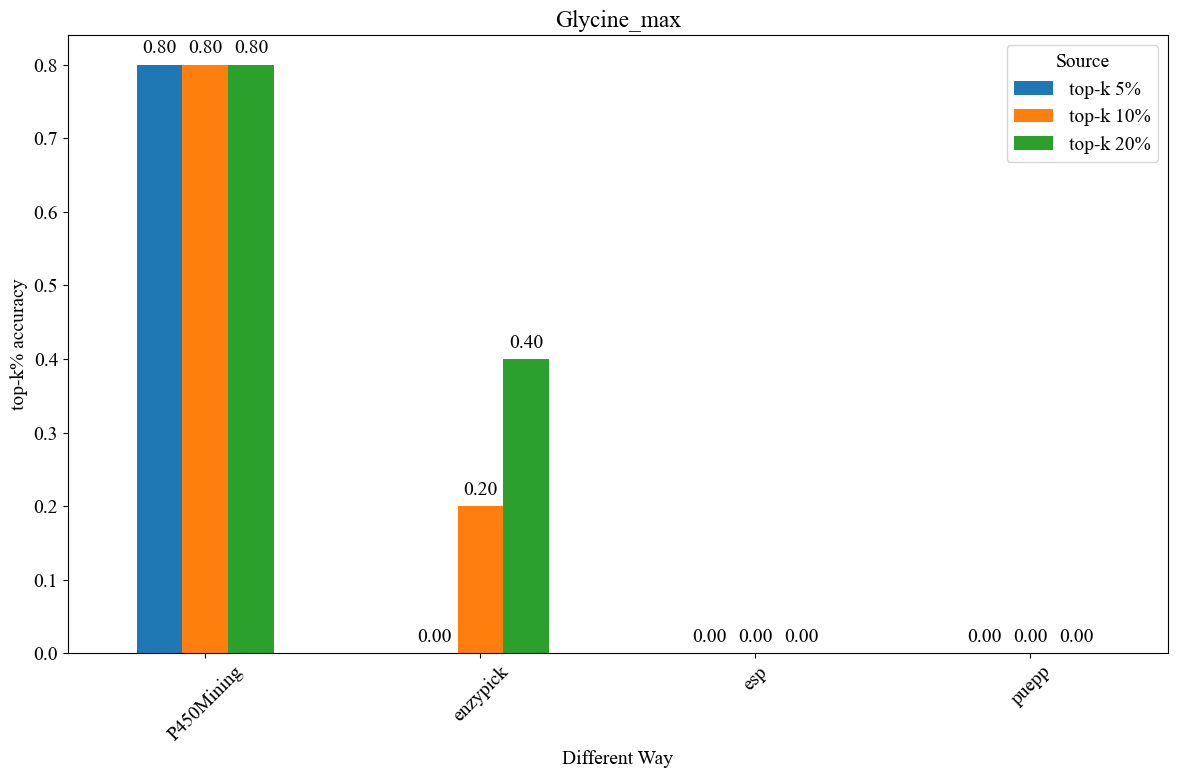

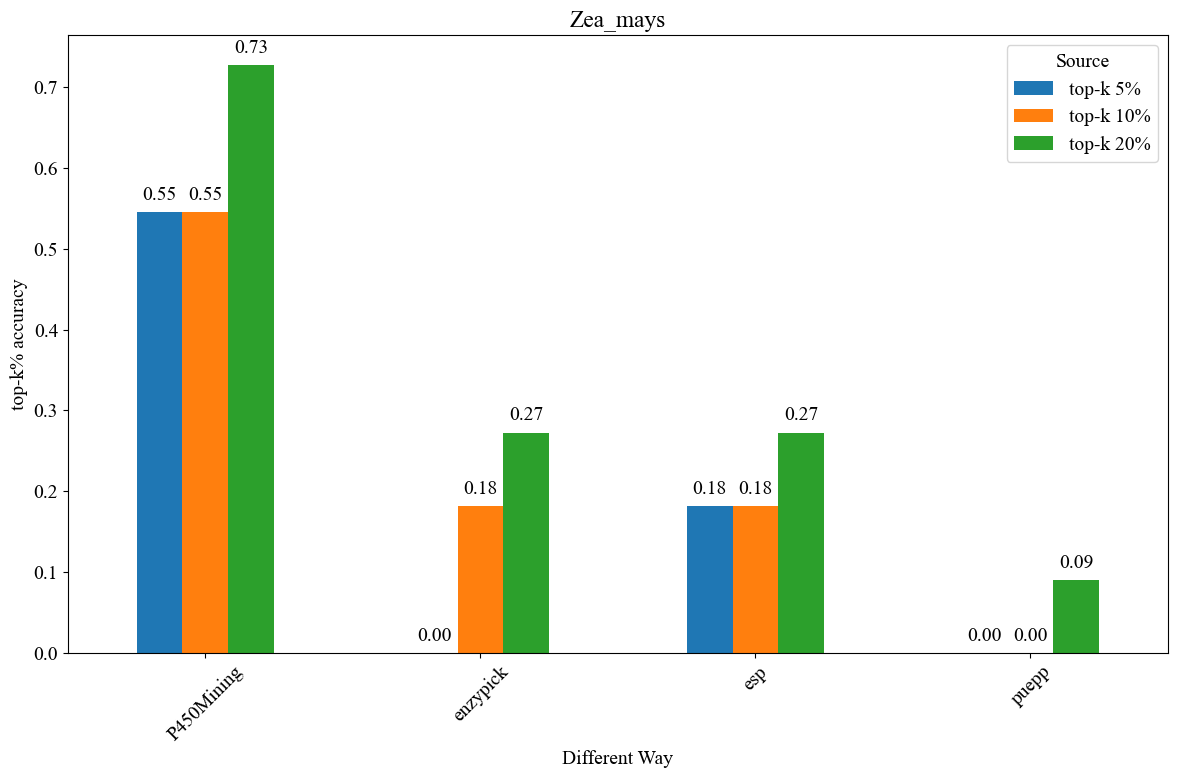

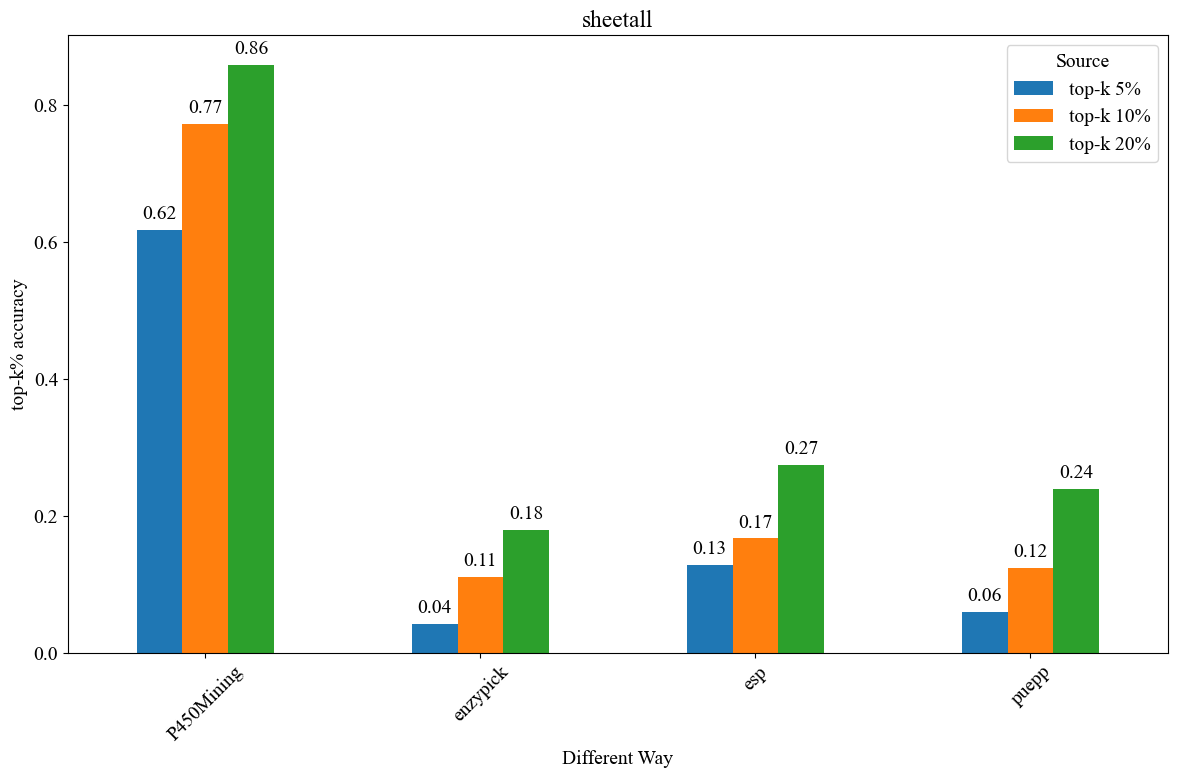

In [ ]:
font_path = "/home/hanxd/data/font/TimesNewRoman.ttf"
font_prop = FontProperties(fname=font_path, size=14)

fontManager.addfont(font_path)
font_name = font_prop.get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["font.size"] = 14


for name, nowdff in dffinalgroup:
    fig, ax = plt.subplots(figsize=(12, 8))
    nowdff.pivot_table(index="source", columns="topk", values="acc").plot(
        kind="bar", ax=ax
    )

    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.text(
                p.get_x() + p.get_width() / 2.0,
                height + 0.01,
                f"{height:.2f}",
                ha="center",
                va="bottom",
            )

    ax.set_xlabel("Different Way")
    ax.set_ylabel("top-k% accuracy")
    ax.set_title(f"{name[0]}")
    plt.xticks(rotation=45)

    handles, labels = plt.gca().get_legend_handles_labels()
    labels = ["top-k " + label + "%" for label in labels]
    plt.legend(handles, labels, title="Source", loc="upper right")
    # plt.legend(title="Source")
    plt.tight_layout()

    plt.savefig(f"../output/{name[0]}_bar_chart_4species.svg")
    plt.show()